In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.datasets import load_diabetes
import matplotlib.pyplot as plt



diabetes = load_diabetes(as_frame=True)
X = diabetes.data
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

n_trees = range(1, 1001, 50)

max_features_values = [2, 6]
rf_results = {m: [] for m in max_features_values}

max_depth_values = [4, 6]
gbm_results = {depth: [] for depth in max_depth_values}


Random Forests

In [2]:
for m in max_features_values:
    for n in n_trees:
        rf = RandomForestRegressor(n_estimators=n, max_features=m, random_state=42)
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred)
        rf_results[m].append(mae)


Gradient Boosting Trees

In [3]:
for depth in max_depth_values:
    for n in n_trees:
        gbm = GradientBoostingRegressor(n_estimators=n, max_depth=depth, random_state=42)
        gbm.fit(X_train, y_train)
        y_pred = gbm.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred)
        gbm_results[depth].append(mae)


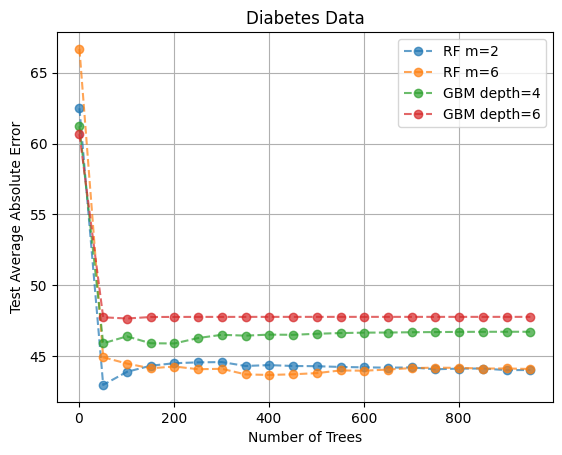

In [7]:
for m, errors in rf_results.items():
    plt.plot(list(n_trees), errors[:len(n_trees)], label=f'RF m={m}', linestyle='--', marker='o', alpha=0.7)

for m, errors in gbm_results.items():
    plt.plot(list(n_trees), errors[:len(n_trees)], label=f'GBM depth={m}', linestyle='--', marker='o', alpha=0.7)

plt.xlabel("Number of Trees")
plt.ylabel("Test Average Absolute Error")
plt.title("Diabetes Data")
plt.legend()
# plt.ylim(0.20, 0.5)
plt.grid()
plt.show()

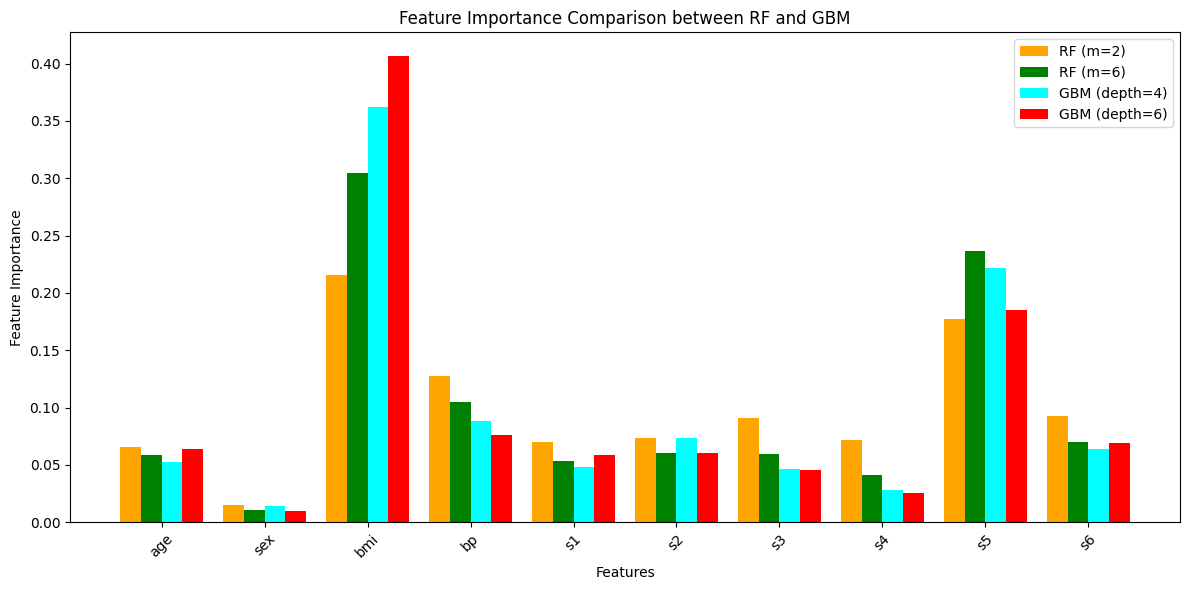


Feature Importance Rankings:

RF (m=2):
bmi: 0.216
s5: 0.178
bp: 0.127
s6: 0.093
s3: 0.091
s2: 0.073
s4: 0.072
s1: 0.070
age: 0.065
sex: 0.015

RF (m=6):
bmi: 0.305
s5: 0.236
bp: 0.105
s6: 0.070
s2: 0.061
s3: 0.060
age: 0.059
s1: 0.053
s4: 0.041
sex: 0.011

GBM (depth=4):
bmi: 0.362
s5: 0.222
bp: 0.088
s2: 0.073
s6: 0.064
age: 0.053
s1: 0.048
s3: 0.046
s4: 0.028
sex: 0.015

GBM (depth=6):
bmi: 0.407
s5: 0.185
bp: 0.076
s6: 0.069
age: 0.064
s2: 0.060
s1: 0.058
s3: 0.046
s4: 0.025
sex: 0.010

Correlation between feature importances of different models:
               RF (m=2)  RF (m=6)  GBM (depth=4)  GBM (depth=6)
RF (m=2)       1.000000  0.964293       0.929669       0.893444
RF (m=6)       0.964293  1.000000       0.986044       0.952491
GBM (depth=4)  0.929669  0.986044       1.000000       0.986075
GBM (depth=6)  0.893444  0.952491       0.986075       1.000000


In [5]:
feature_names = diabetes.feature_names

rf_m2 = RandomForestRegressor(n_estimators=1000, max_features=2, random_state=42)
rf_m6 = RandomForestRegressor(n_estimators=1000, max_features=6, random_state=42)
gbm_d4 = GradientBoostingRegressor(n_estimators=1000, max_depth=4, random_state=42)
gbm_d6 = GradientBoostingRegressor(n_estimators=1000, max_depth=6, random_state=42)

models = {'RF (m=2)': rf_m2, 'RF (m=6)': rf_m6, 
          'GBM (depth=4)': gbm_d4, 'GBM (depth=6)': gbm_d6}

for name, model in models.items():
    model.fit(X_train, y_train)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'RF (m=2)': rf_m2.feature_importances_,
    'RF (m=6)': rf_m6.feature_importances_,
    'GBM (depth=4)': gbm_d4.feature_importances_,
    'GBM (depth=6)': gbm_d6.feature_importances_
})

plt.figure(figsize=(12, 6))
x = np.arange(len(feature_names))
width = 0.2

plt.bar(x - 1.5*width, importance_df['RF (m=2)'], width, label='RF (m=2)', color='orange')
plt.bar(x - 0.5*width, importance_df['RF (m=6)'], width, label='RF (m=6)', color='green')
plt.bar(x + 0.5*width, importance_df['GBM (depth=4)'], width, label='GBM (depth=4)', color='cyan')
plt.bar(x + 1.5*width, importance_df['GBM (depth=6)'], width, label='GBM (depth=6)', color='red')

plt.xlabel('Features')
plt.ylabel('Feature Importance')
plt.title('Feature Importance Comparison between RF and GBM')
plt.xticks(x, feature_names, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

print("\nFeature Importance Rankings:")
for model in ['RF (m=2)', 'RF (m=6)', 'GBM (depth=4)', 'GBM (depth=6)']:
    print(f"\n{model}:")
    sorted_importance = importance_df.sort_values(by=model, ascending=False)
    for _, row in sorted_importance.iterrows():
        print(f"{row['Feature']}: {row[model]:.3f}")

importance_corr = importance_df.iloc[:, 1:].corr()
print("\nCorrelation between feature importances of different models:")
print(importance_corr)

In [8]:
print(f"Target variable range: {min(y)} to {max(y)}")
print(f"Target variable standard deviation: {np.std(y)}")

Target variable range: 25.0 to 346.0
Target variable standard deviation: 77.00574586945044


The slightly higher importance assigned to BMI by GBM compared to RF (0.40 vs 0.30) might be due to GBM's sequential learning approach, which can increase strong predictors as it focus on correcting errors. RF's lower BMI importance and more balanced distribution across the features (especially for S5 and BP) could be because of random feature sampling at each split, forcing it to consider multiple variables. However, these difference are small and both models essentially agree on the key predictors suggesting BMI, S5, and BP have strong relationships with diabetes progression, which makes sense because body mass, blood sugar and blood pressure are known diabetes risk factors.